# Image Classification with Fixed Filter Banks

In this lab you'll build an image classifier. It's a linear classifier where every feature comes from a bank of convolution filters that you design by hand.
Pipeline:

- raw image $\mathbf{x}$
- extract filter bank $x * w_k$
- nonlinearity $\rho(x \ast w_k)$
- pooling $P\big(\rho(x \ast w_k)\big)$
- linear classifier

The goal of the lab is the exploration of the impact of different design choices of feature banks.

Notice that: 
- all the filters are linear filters. As a result, they will not improve a linear classifier if we don't have some non-linear transformation. This is why we have a nonlinearity and pooling.
- this is a shallow feature extractor, unlike a CNN.

We start from a small baseline bank (identity, blur, Sobel) and add filters that respond to more **orientations**, **scales** or **frequencies**.

**Note:**
- You can change the filters, the nonlinearity and pooling. Keep the classifier as is
- Use the validation set to evaluate new additions and their hyperparameters (e.g. scale parameters)
- For each change, write down what you expect, run it, then annotate the results. Look at the feature maps to see if they extract the features you expect
- a flat feature bank should easily reach around 89% accuracy on the validation.

**Dataset.** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist): 28×28 grayscale images of clothing in 10 classes. 

In [1]:
import os, gzip, time, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import warnings
from scipy.linalg import LinAlgWarning
warnings.filterwarnings("ignore", category=LinAlgWarning)   # pooled features are highly correlated. Not a big issue for classification, but it triggers a warning.

plt.rcParams.update({"figure.dpi": 100, "image.interpolation": "nearest"})
SEED = 1234567

# Data

We use 20,000 training images, 10,000 validation images and 10,000 test images. Data is automatically downloaded.

In [2]:
DATA_DIR = "data"
URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
FILES = {
    "train_x": "train-images-idx3-ubyte.gz", "train_y": "train-labels-idx1-ubyte.gz",
    "test_x":  "t10k-images-idx3-ubyte.gz",  "test_y":  "t10k-labels-idx1-ubyte.gz",
}

def load_data(name):
    os.makedirs(DATA_DIR, exist_ok=True)
    path = os.path.join(DATA_DIR, FILES[name])
    if not os.path.exists(path):
        print("downloading", FILES[name])
        urllib.request.urlretrieve(URL + FILES[name], path)
    with gzip.open(path) as f:
        raw = f.read()
    if name.endswith("_x"):
        return np.frombuffer(raw, np.uint8, offset=16).reshape(-1, 28, 28).astype(np.float32) / 255.0
    return np.frombuffer(raw, np.uint8, offset=8).astype(np.int64)

X_all, y_all = load_data("train_x"), load_data("train_y")
X_test, y_test = load_data("test_x"), load_data("test_y")

perm = np.random.default_rng(SEED).permutation(len(X_all))
X_train, y_train = X_all[perm[:20000]], y_all[perm[:20000]]
X_val,   y_val   = X_all[perm[50000:]], y_all[perm[50000:]]

CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("train", X_train.shape, " val", X_val.shape, " test", X_test.shape)

downloading train-images-idx3-ubyte.gz
downloading train-labels-idx1-ubyte.gz
downloading t10k-images-idx3-ubyte.gz
downloading t10k-labels-idx1-ubyte.gz
train (20000, 28, 28)  val (10000, 28, 28)  test (10000, 28, 28)


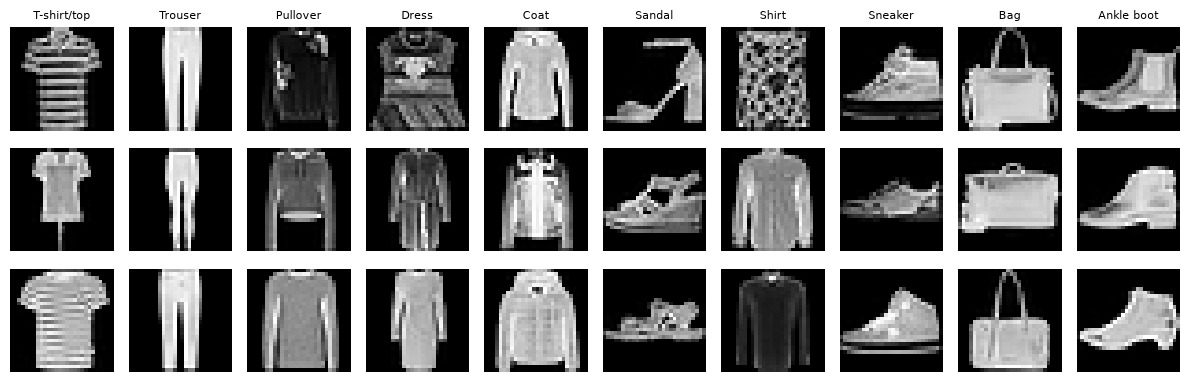

In [3]:
fig, axes = plt.subplots(3, 10, figsize=(12, 4))
for c in range(10):
    idx = np.where(y_train == c)[0][:3]
    for r in range(3):
        axes[r, c].imshow(X_train[idx[r]], cmap="gray")
        axes[r, c].axis("off")
    axes[0, c].set_title(CLASSES[c], fontsize=8)
plt.tight_layout(); plt.show()

# Model Pipeline

- `extract_features(X, bank, nonlinearity, pool_size, pool_type, power)`
  1. convolves every image with every filter (`'same'` output size, zero padding),
  2. applies a pointwise nonlinearity:
     - `'none'`: $r$
     - `'abs'`: $|r|$
     - `'square'`: $r^2$
     - `'ReLU'`: $\max(r,0)$
  3. pools non-overlapping `pool_size × pool_size` blocks (`'avg'` or `'max'`),
  4. optionally rescale the pooled features, $z \leftarrow z^{\text{power}}$ 
- `evaluate(bank, name, ...)` extracts features for train and validation, standardizes them, fits a ridge classifier


In [4]:
NONLINEARITIES = {
    "none":    lambda r: [r],
    "abs":     lambda r: [np.abs(r)],
    "square":  lambda r: [r ** 2],
    "rectify": lambda r: [np.maximum(r, 0)],
}


def convolve(X, kernel):
    # X: (N, H, W) batch of images, kernel: (h, w). Returns (N, H, W).
    return signal.fftconvolve(X, np.asarray(kernel, np.float32)[None], mode="same", axes=(1, 2))


def pool(R, size, kind="avg"):
    # Non-overlapping size x size pooling of (N, H, W) maps -> (N, H//size * W//size).
    N, H, W = R.shape
    R = R[:, :H // size * size, :W // size * size].reshape(N, H // size, size, W // size, size)
    R = R.mean(axis=(2, 4)) if kind == "avg" else R.max(axis=(2, 4))
    return R.reshape(N, -1)


def extract_features(X, bank, nonlinearity="abs", pool_size=4, pool_type="avg", power=1.0):
    feats = []
    for k in bank:
        for r in NONLINEARITIES[nonlinearity](convolve(X, k)):
            feats.append(pool(r, pool_size, pool_type))
    F = np.concatenate(feats, axis=1)
    if power != 1.0:
        F = np.sign(F) * np.abs(F) ** power
    return F


def fit_and_score(F_tr, y_tr, F_ev, y_ev, alpha=1.0):
    clf = make_pipeline(StandardScaler(), RidgeClassifier(alpha=alpha))
    clf.fit(F_tr, y_tr)
    return clf.score(F_ev, y_ev)


def evaluate(bank, name, **cfg):
    # Fit on the training split, report accuracy on the validation split.
    t = time.time()
    F_tr, F_val = extract_features(X_train, bank, **cfg), extract_features(X_val, bank, **cfg)
    acc = fit_and_score(F_tr, y_train, F_val, y_val)
    print(f"{name:<40s} val acc = {acc:.4f}   #features = {F_tr.shape[1]:5d}   ({time.time()-t:.1f}s)")
    return acc


def evaluate_custom(feature_fn, name):
    # Same as evaluate(), but feature_fn(X) -> (N, D) is any fixed feature map.
    t = time.time()
    F_tr, F_val = feature_fn(X_train), feature_fn(X_val)
    acc = fit_and_score(F_tr, y_train, F_val, y_val)
    print(f"{name:<40s} val acc = {acc:.4f}   #features = {F_tr.shape[1]:5d}   ({time.time()-t:.1f}s)")
    return acc

In [5]:
def show_bank(bank, titles=None, ncols=8, size=1.4):
    n = len(bank); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows + 0.3), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis("off")
        if i < n:
            k = np.asarray(bank[i]); m = np.abs(k).max() + 1e-12
            ax.imshow(k, cmap="RdBu_r", vmin=-m, vmax=m)
            ax.set_title(titles[i] if titles else f"{k.shape[0]}x{k.shape[1]}", fontsize=7)
    plt.tight_layout(); plt.show()


def show_responses(img, bank, titles=None, nonlinearity="abs"):
    n = len(bank)
    fig, axes = plt.subplots(2, n + 1, figsize=(1.6 * (n + 1), 3.4), squeeze=False)
    axes[0, 0].imshow(img, cmap="gray"); axes[0, 0].set_title("input", fontsize=8)
    axes[1, 0].axis("off")
    for i, k in enumerate(bank):
        r = convolve(img[None], k)[0]
        m = np.abs(r).max() + 1e-12
        axes[0, i + 1].imshow(r, cmap="RdBu_r", vmin=-m, vmax=m)
        axes[0, i + 1].set_title(titles[i] if titles else f"filter {i}", fontsize=8)
        rp = NONLINEARITIES[nonlinearity](r)[0]
        axes[1, i + 1].imshow(pool(rp[None], 4).reshape(7, 7), cmap="magma")
    for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
    axes[0, 0].set_ylabel("response"); axes[1, 1].set_ylabel(f"{nonlinearity} + pool 4")
    plt.tight_layout(); plt.show()


def show_conv_responses(bank, titles=None):
    for n in range(0, len(bank)):
        fig, axes = plt.subplots(3, 10, figsize=(12, 4))
        plt.suptitle(titles[n] if titles else f"filter {n}", fontsize=10)
        for c in range(10):
            idx = np.where(y_train == c)[0][:3]
            for r in range(3):
                img = X_train[idx[r]]
                res = convolve(img[None], bank[n])[0]
                axes[r, c].imshow(res, cmap="gray")
                axes[r, c].axis("off")
            axes[0, c].set_title(CLASSES[c], fontsize=8)

## Raw pixels

A bank made of a single **identity** (delta) filter, with no nonlinearity and no pooling. Equivalent to a linear classifier on the raw pixels (784 features).

pixels (identity, none, pool 1)          val acc = 0.8128   #features =   784   (1.0s)


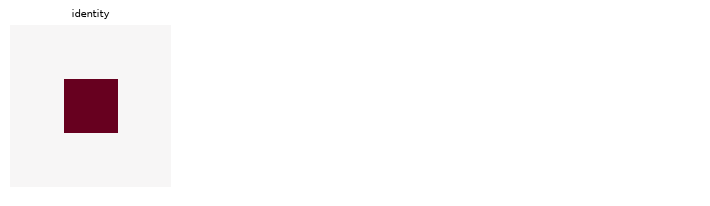

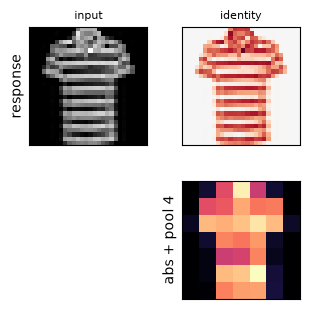

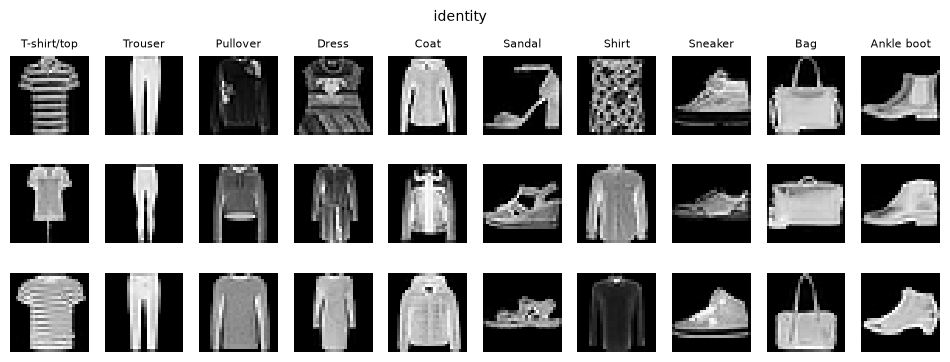

In [6]:
identity = np.array([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]], float)

evaluate([identity], "pixels (identity, none, pool 1)", nonlinearity="none", pool_size=1)

show_bank([identity], ["identity"], ncols=4, size=1.8)
show_responses(X_train[1], [identity], ["identity"])
show_conv_responses([identity], titles=["identity"])


## Baseline filter bank

The baseline has four 3×3 filters: identity, box blur, Sobel-x and Sobel-y. Responses go through the nonlinearity and the 4×4 average pooling, which gives 4 × 7 × 7 = 196 features.

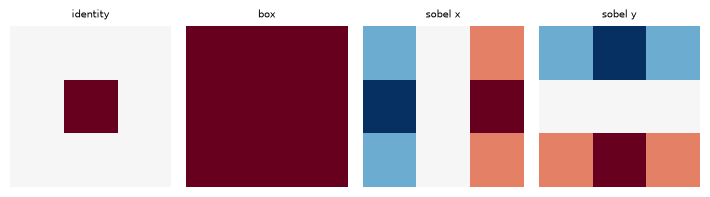

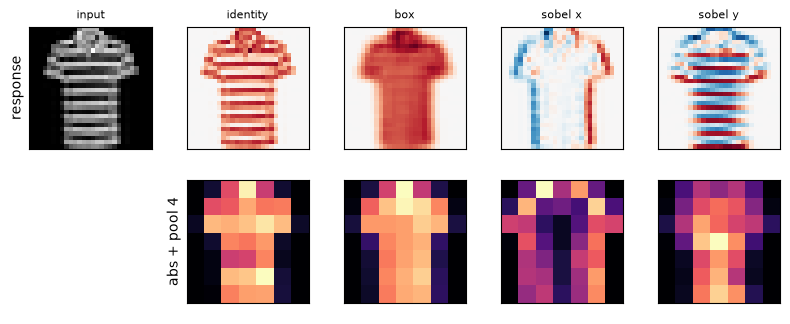

baseline (id, box, sobel x/y)            val acc = 0.8381   #features =   196   (2.5s)


0.8381

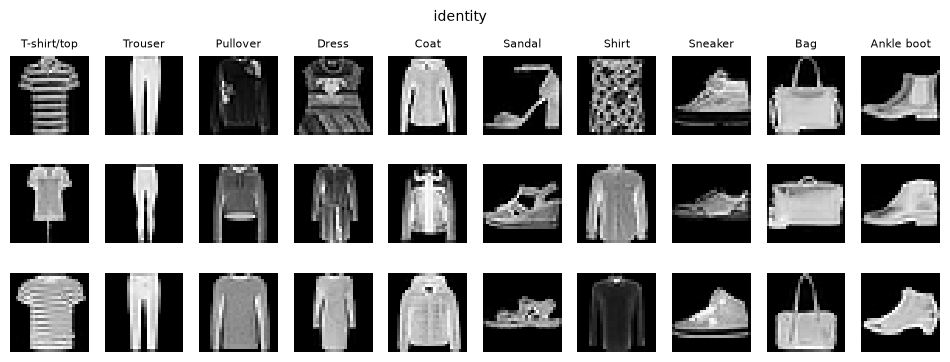

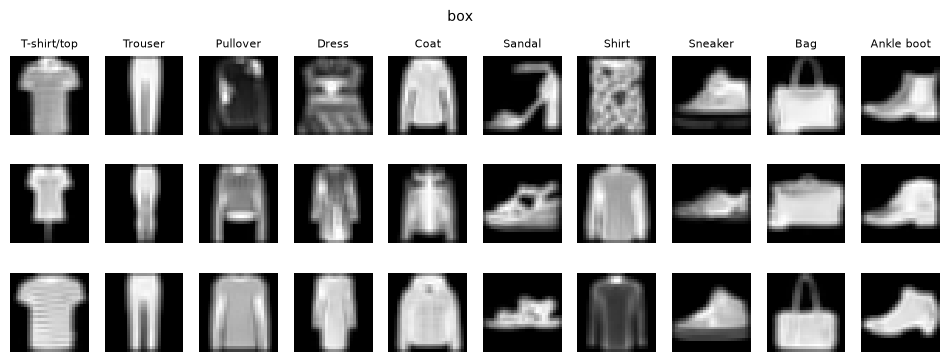

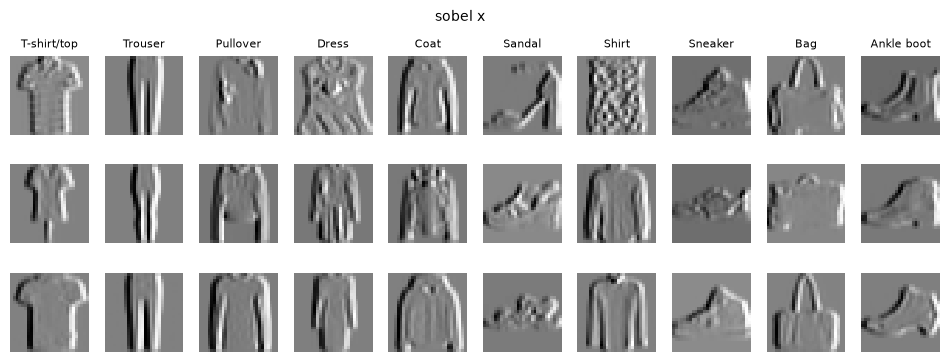

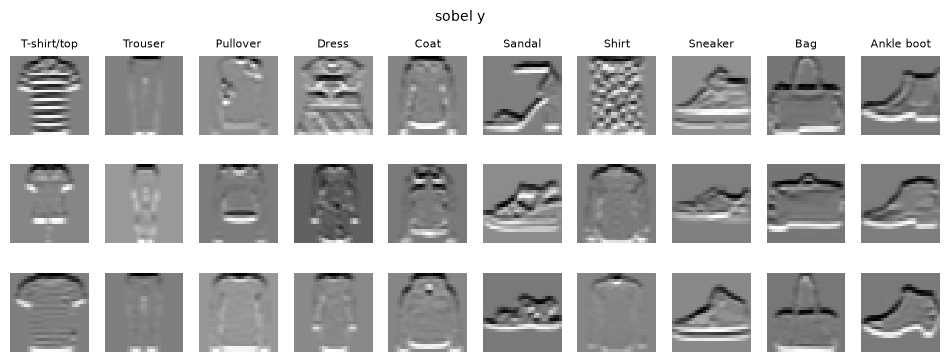

In [8]:
box = np.ones((3, 3)) * 1/9
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = sobel_x.T

baseline_bank   = [identity, box, sobel_x, sobel_y]
baseline_titles = ["identity", "box", "sobel x", "sobel y"]

show_bank(baseline_bank, baseline_titles, ncols=4, size=1.8)
show_responses(X_train[1], baseline_bank, baseline_titles)

show_conv_responses(baseline_bank, titles=baseline_titles)

evaluate(baseline_bank, "baseline (id, box, sobel x/y)")

**QB.1** The baseline has 4× *fewer* features than raw pixels. Test it with and without the raw pixel (identity filter). Which one is better? How does pooling help?

**QB.2** Look at the response maps. Which garments do you expect `sobel x` to separate well from `sobel y`? (e.g. trousers and sneakers)

**Answer.** Trousers, dresses and bags have long vertical outlines, which give strong $|\partial_x|$ responses. Sandals have many horizontal straps, and shirts/pullovers have horizontal hems and sleeves (strong $|\partial_y|$). The *ratio* of the two responses in each cell acts as a crude local orientation descriptor.

## Exercise: Complete the edge family

Sobel-x and Sobel-y only respond strongly to vertical and horizontal edges. Extend the baseline with:

1. two **diagonal** 3×3 edge detectors (45° and 135°), built in the same spirit as Sobel: a derivative across the edge and smoothing along it;
2. a 3×3 **Laplacian** (a second-derivative, isotropic "blob/line" detector). You can take this kernel from the slides.

Before running: which of the two additions do you expect to help more?

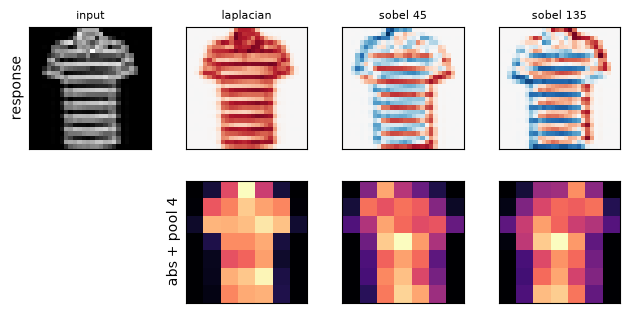

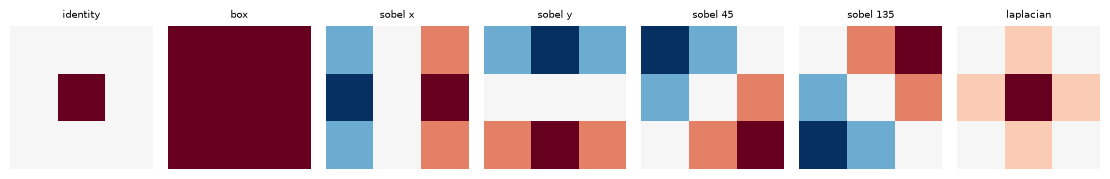

baseline + diagonals                     val acc = 0.8596   #features =   294   (3.2s)
baseline + laplacian                     val acc = 0.8382   #features =   245   (2.5s)
baseline + diagonals + laplacian         val acc = 0.8599   #features =   343   (3.6s)


0.8599

In [11]:
sobel_d45  = np.array([[-2, -1, 0], [-1, 0, 1], [0, 1, 2]])
sobel_d135 = np.array([[0, 1, 2], [-1, 0, 1], [-2, -1, 0]])
laplacian  = np.array([[0, 1, 0], [1, 4, 1], [0, 1, 0]])

diag_bank = baseline_bank + [sobel_d45, sobel_d135]
ex1_bank  = diag_bank + [laplacian]
ex1_titles = baseline_titles + ["sobel 45", "sobel 135", "laplacian"]

show_responses(X_train[1], [laplacian, sobel_d45, sobel_d135], ["laplacian", "sobel 45", "sobel 135"])

show_bank(ex1_bank, ex1_titles, ncols=7, size=1.6)
evaluate(diag_bank, "baseline + diagonals")
evaluate(baseline_bank + [laplacian], "baseline + laplacian")
evaluate(ex1_bank, "baseline + diagonals + laplacian")

**Question**: Ablate the use of diagonals and Laplacian (test them both separately). Which features are more important?

## Exercise: Gaussian derivative filters and Scale

3×3 filters only see structure at the finest scale. Fashion-MNIST items also differ in coarser structure: the gap between trouser legs, a collar, a sleeve.

Build a filter bank of image derivatives at different scales. Here you have the Gaussian and Gaussian derivative, but you can also add the binomial.

In [12]:
def gaussian_kernel(sigma):
    # Normalized 2D Gaussian (sums to 1) on a (2R+1)x(2R+1) grid
    R = int(np.ceil(3 * sigma))
    X, Y = np.meshgrid(np.arange(-R, R + 1), np.arange(-R, R + 1))
    G = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return G / G.sum()

def gaussian_derivative_kernel(sigma, order):
    # order in {'x', 'y', 'xx', 'yy', 'xy'}; same support as gaussian_kernel(sigma).
    R = int(np.ceil(3 * sigma))
    X, Y = np.meshgrid(np.arange(-R, R + 1), np.arange(-R, R + 1))
    G = gaussian_kernel(sigma)
    s2 = sigma**2
    return {
        "x":  -X / s2 * G,
        "y":  -Y / s2 * G,
        "xx": (X**2 / s2**2 - 1 / s2) * G,
        "yy": (Y**2 / s2**2 - 1 / s2) * G,
        "xy": X * Y / s2**2 * G,
    }[order]

**Question:** Evaluate different scales and report their accuracy.

In [ ]:
assert False, "Add gaussian derivative bank"
gd_bank, gd_titles = None, None
show_bank(gd_bank, gd_titles, ncols=6)
gd_bank = [identity] + gd_bank


## Orientation and frequency, with Gabor filters

[Gabor filters](https://en.wikipedia.org/wiki/Gabor_filter) are a very popular filter family that we did not discussed yet.
Gabor filters model simple cells in V1, and they closely resemble the first-layer filters that CNNs learn.

A Gabor filter is tuned to a location, orientation, and frequency.

Since we did not study Gabor filters in class, they are already implemented and ready to use.

In [ ]:
def gabor_kernel(sigma, theta, wavelength, phase=0.0):
    R = int(np.ceil(3 * sigma))
    X, Y = np.meshgrid(np.arange(-R, R + 1), np.arange(-R, R + 1))
    Xr = X * np.cos(theta) + Y * np.sin(theta)
    Yr = -X * np.sin(theta) + Y * np.cos(theta)
    g = np.exp(-(Xr**2 + Yr**2) / (2 * sigma**2)) * np.cos(2 * np.pi * Xr / wavelength + phase)
    g = g - g.mean()
    return g / np.abs(g).sum()

In [ ]:
SCALES = [(1.5, 4), (3, 8)]

def gabor_bank(n_orient, scales=SCALES, phases=(0, np.pi / 2)):
    bank, titles = [], []
    for sigma, lam in scales:
        for theta in np.arange(n_orient) * np.pi / n_orient:
            for psi in phases:
                bank.append(gabor_kernel(sigma, theta, lam, psi))
                titles.append(f"{np.degrees(theta):.0f}° λ={lam} {'e' if psi == 0 else 'o'}")
    return bank, titles

b, t = gabor_bank(4)
show_bank(b, t, ncols=8)

gabor_acc = {}
for n in [2, 4, 8]:
    gabor_acc[n] = evaluate([identity] + gabor_bank(n)[0], f"gabor {n} orient. x 2 scales x 2 phases")

plt.figure(figsize=(4, 3))
plt.plot(list(gabor_acc), list(gabor_acc.values()), "o-")
plt.xlabel("# orientations"); plt.ylabel("val accuracy"); plt.xticks([2, 4, 8]); plt.grid(alpha=.3); plt.show()

## Exercise: Nonlinearity and pooling

Evaluate the role of non-linearity and pooling. You can evaluate different pool sizes too.

In [ ]:
assert False, "test with/without pooling and different non-linearities"
assert False, "evaluate the pooling-size/accuracy trade-off"


**Q:** Without a nonlinearity (`none`), the result should be no better than **raw pixels** no matter how many filters you add. Check this empirically.

**Q:** Plot a pooling-size/accuracy curve. What are the advantages and disadvantages of pooling? What is gained and what is lost as the pool grows?

**Q:** `power=0.5` compresses large feature values. Why might that help a *linear* classifier?


## Exercise: Random filters

Build a bank of **random** filters (e.g. randomly generated 5×5 kernels). With enough filters, you should get results close to the hand-designed filters.

In [ ]:
assert False, "create and evaluate a random filter bank"

evaluate(random_bank(4),  "random 4 filters (vs baseline)")
evaluate(random_bank(13), "random 13 filters (vs gauss-deriv)")
evaluate(random_bank(34), "random 34 filters (vs gabor 8)")
show_bank(random_bank(8), ncols=8)

**Q6.1** Compare random filters at different bank sizes.

**Q6.2** Discuss advantages and disadvantages of random vs handmade filters (e.g. efficiency vs explainability).

## Challenge: Improve the filter bank

There are several things you can implement to improve this simple detector:
- combine and extend any of the banks above
- investigate different nonlinearity, pooling and `power`
- write your own fixed feature map and evaluate it with `evaluate_custom(feature_fn, name)`. For example:
  - **spatial pyramid**: concatenate pooling at several sizes
  - **a second layer**: after the non-linearity, you can filter the un-pooled response maps again with a second fixed bank.

As before, report the validation accuracy and the number of features.

In [ ]:
assert False

## Final evaluation on the test set

All the results up to now were on the validation set. Test some configurations on the test set to obtain the final results.
For optimal results, before testing each configuration is retrained on train + validation.

In [ ]:
FINAL_BANK = baseline_bank    # best validation entry
FINAL_CFG  = dict(nonlinearity="abs", pool_size=4, pool_type="avg", power=0.5)

X_trval, y_trval = np.concatenate([X_train, X_val]), np.concatenate([y_train, y_val])
for name, bank, cfg in [("pixels", [identity], dict(nonlinearity="none", pool_size=1)),
                        ("baseline", baseline_bank, {}),
                        ("final", FINAL_BANK, FINAL_CFG)]:
    acc = fit_and_score(extract_features(X_trval, bank, **cfg), y_trval,
                        extract_features(X_test, bank, **cfg), y_test)
    print(f"{name:<10s} TEST accuracy = {acc:.4f}")

## Wrap-up

The main thing we are missing is hierarchy and learned filters. To do that, we will need CNNs.

In [ ]:
from sklearn.metrics import confusion_matrix
F_tv, F_te = extract_features(X_trval, FINAL_BANK, **FINAL_CFG), extract_features(X_test, FINAL_BANK, **FINAL_CFG)
clf = make_pipeline(StandardScaler(), RidgeClassifier(alpha=1.0)).fit(F_tv, y_trval)
cm = confusion_matrix(y_test, clf.predict(F_te), normalize="true")
plt.figure(figsize=(6, 5)); plt.imshow(cm, cmap="Blues")
plt.xticks(range(10), CLASSES, rotation=60, fontsize=8); plt.yticks(range(10), CLASSES, fontsize=8)
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0.02: plt.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=6,
                                     color="white" if cm[i, j] > .5 else "black")
plt.xlabel("predicted"); plt.ylabel("true"); plt.colorbar(); plt.tight_layout(); plt.show()